## 1. Chargement et exploration du dataset CIFAR-10

Dans cette section, nous allons travailler avec le jeu de données **CIFAR-10**.

### Présentation du dataset

CIFAR-10 est un ensemble d’images couleur de petite taille (32×32 pixels, 3 canaux RGB).  
Il contient **10 classes** différentes, par exemple :
- avion (airplane)
- automobile (automobile)
- oiseau (bird)
- chat (cat)
- cerf (deer)
- chien (dog)
- grenouille (frog)
- cheval (horse)
- bateau (ship)
- camion (truck)

Le dataset est divisé en :
- **50 000 images** pour l’entraînement,
- **10 000 images** pour le test.

### Objectifs de cette partie

1. **Charger le dataset CIFAR-10**
   - Récupérer les ensembles d’entraînement et de test (images + labels).

2. **Inspecter les dimensions**
   - Vérifier :
     - le nombre d’images d’entraînement et de test,
     - la forme d’une image (hauteur, largeur, nombre de canaux),
     - la distribution des labels (combien d’images par classe).

3. **Visualiser des exemples**
   - Afficher au moins **12 images** avec leur classe (label) textuelle.

4. **Normaliser les pixels**
   - Les valeurs de pixels sont initialement dans le domaine **[0, 255]**.
   - On va les ramener dans **[0, 1]** (division par 255).
   - La normalisation permet :
     - de stabiliser l’entraînement,
     - d’accélérer la convergence,
     - de limiter les problèmes numériques.

5. **Vérifier la normalisation**
   - Avant et après, on vérifie :
     - le min et max des pixels,
     - le type des données (`uint8` → `float32`).

À la fin de cette section, nous aurons :
- une compréhension de la structure de CIFAR-10,
- une visualisation de quelques exemples d’images,
- des données prêtes à être utilisées par un réseau de neurones (images normalisées).


Cellule de code n°1 – Import + chargement + inspection

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from keras.datasets import cifar10

print("Version de TensorFlow :", tf.__version__)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)
print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)


Version de TensorFlow : 2.20.0
x_train shape : (50000, 32, 32, 3)
y_train shape : (50000,)
x_test shape  : (10000, 32, 32, 3)
y_test shape  : (10000,)


Visualiser 12 images avec leurs labels

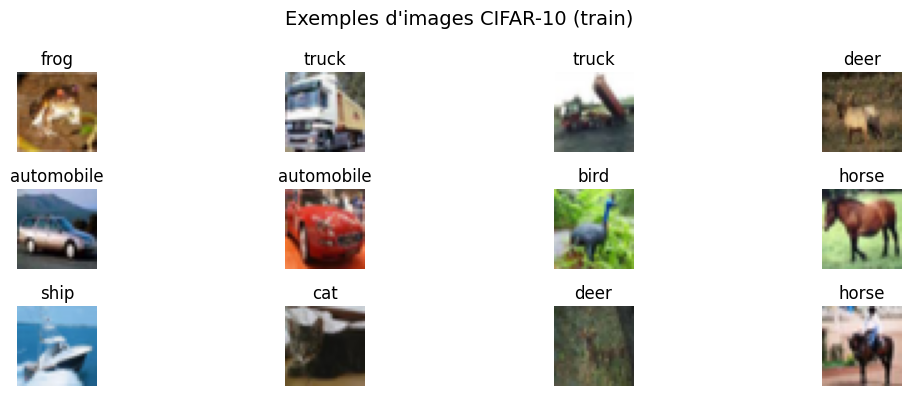

In [6]:
# ==========================================
# 6. Visualisation de quelques images CIFAR-10
# ==========================================

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

num_images = 12

plt.figure(figsize=(12, 4))

for i in range(num_images):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])        # image couleur 32x32x3
    label_idx = y_train[i]
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.suptitle("Exemples d'images CIFAR-10 (train)", fontsize=14)
plt.tight_layout()
plt.show()


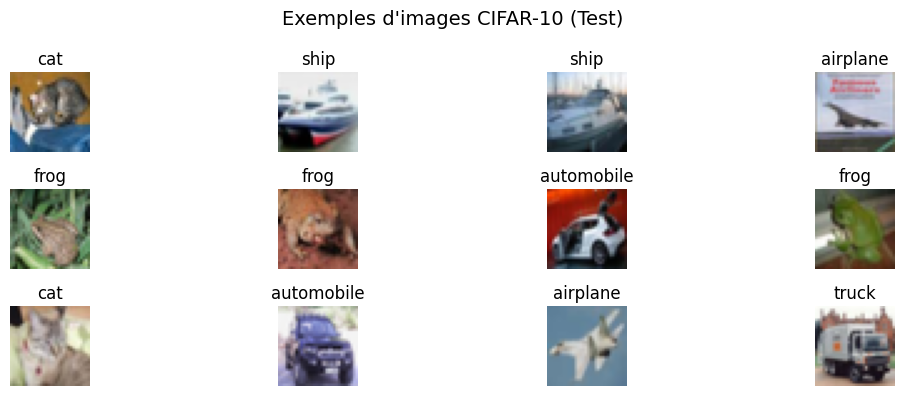

In [7]:
# ==========================================
# 6. Visualisation de quelques images CIFAR-10
# ==========================================

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

num_images = 12

plt.figure(figsize=(12, 4))

for i in range(num_images):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])        # image couleur 32x32x3
    label_idx = y_test[i]
    plt.title(class_names[label_idx])
    plt.axis("off")

plt.suptitle("Exemples d'images CIFAR-10 (Test)", fontsize=14)
plt.tight_layout()
plt.show()


Normalisation des pixels + vérification

In [8]:
# ==========================================
# 7. Valeurs AVANT normalisation
# ==========================================

print("Valeurs de pixels AVANT normalisation :")
print("  min de x_train :", x_train.min())
print("  max de x_train :", x_train.max())
print("  min de x_test  :", x_test.min())
print("  max de x_test  :", x_test.max())

# ==========================================
# 8. Normalisation des images en [0, 1]
# ==========================================

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm  = x_test.astype("float32") / 255.0

# ==========================================
# 9. Valeurs APRÈS normalisation
# ==========================================

print("\nValeurs de pixels APRÈS normalisation :")
print("  min de x_train_norm :", x_train_norm.min())
print("  max de x_train_norm :", x_train_norm.max())
print("  min de x_test_norm  :", x_test_norm.min())
print("  max de x_test_norm  :", x_test_norm.max())

print("\nType des données après normalisation :", x_train_norm.dtype)


Valeurs de pixels AVANT normalisation :
  min de x_train : 0
  max de x_train : 255
  min de x_test  : 0
  max de x_test  : 255

Valeurs de pixels APRÈS normalisation :
  min de x_train_norm : 0.0
  max de x_train_norm : 1.0
  min de x_test_norm  : 0.0
  max de x_test_norm  : 1.0

Type des données après normalisation : float32


Le dataset CIFAR-10 contient 60 000 images RGB de 32×32 pixels appartenant à 10 classes :
airplane, automobile, bird, cat, deer, dog, frog, horse, ship et truck.

Les données sont réparties en :
- 50 000 images pour l’entraînement
- 10 000 images pour le test

Nous avons d’abord exploré le dataset :
- les images sont petites et parfois floues,
- plusieurs classes peuvent être visuellement proches (ex : cheval vs cerf),
- ce qui rend la classification plus difficile que sur MNIST.

Ensuite nous avons affiché 12 exemples, confirmant la variété et la complexité des images.

Les valeurs des pixels sont initialement dans [0,255].
Nous les avons normalisées dans [0,1], en convertissant en float32.

Cela est indispensable pour :
- stabiliser l’optimisation,
- accélérer l'entraînement,
- éviter des instabilités numériques.

Après normalisation, les valeurs min et max deviennent 0.0 et 1.0.


## 2. Construction d’un premier réseau MLP (Multilayer Perceptron)

Objectifs :
- Aplatir les images CIFAR-10 (32×32×3 = 3072 valeurs d’entrée)
- Construire un MLP simple composé de :
  - une couche Dense cachée,
  - une autre Dense optionnelle,
  - une couche Dense finale avec softmax (10 classes)
- Compiler le modèle (loss = categorical_crossentropy, optimizer = Adam)
- Afficher le résumé du modèle et analyser le nombre de paramètres

Ce modèle servira de baseline pour les comparaisons suivantes (dropout, CNN…)


In [9]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# ==========================================
# 1. Construction du MLP
# ==========================================

model_mlp = Sequential([
    Flatten(input_shape=(32, 32, 3)),   # transforme (32,32,3) en vecteur de 3072
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# ==========================================
# 2. Compilation
# ==========================================

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# 3. Résumé du modèle
# ==========================================

model_mlp.summary()


c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Notre premier modèle MLP pour CIFAR-10 est constitué d'une couche Flatten
qui convertit chaque image RGB 32×32×3 en un vecteur de 3 072 valeurs.

La première couche cachée Dense possède 256 neurones, ce qui représente
786 688 paramètres trainables. Cela provient des 3 072 entrées multipliées
par 256 neurones, plus 256 biais.

La seconde couche cachée Dense contient 128 neurones, soit 32 896 paramètres.
Enfin, la couche de sortie est constituée de 10 neurones correspondant aux 10
classes du dataset, avec activation softmax (1 290 paramètres).

Le réseau contient au total :

    Total params: 820 874 (~ 3.13 MB)

Ce nombre élevé de paramètres est dû au fait que l’image est entièrement aplatie,
donc l’architecture ne tire pas parti des relations spatiales entre pixels.


## 3. Entraînement du modèle MLP
- 10% des données d'entraînement sont utilisées pour la validation
- Entraînement sur 10 époques
- Suivi des courbes Loss / Accuracy


In [10]:
# ==========================================
# 3. Entraînement du modèle MLP
# ==========================================

history_mlp = model_mlp.fit(
    x_train_norm, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.3166 - loss: 1.9051 - val_accuracy: 0.3732 - val_loss: 1.7776
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3881 - loss: 1.7162 - val_accuracy: 0.3992 - val_loss: 1.7007
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4148 - loss: 1.6409 - val_accuracy: 0.4290 - val_loss: 1.6119
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4367 - loss: 1.5785 - val_accuracy: 0.4288 - val_loss: 1.6054
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4536 - loss: 1.5395 - val_accuracy: 0.4184 - val_loss: 1.6314
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4678 - loss: 1.4981 - val_accuracy: 0.4494 - val_loss: 1.5618
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4738 - loss: 1.4756 - val_accuracy: 0.4634 - val_loss: 1.4982
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4845 - loss: 1.4501 - val_accu

Partie 4 — Tracer Accuracy & Loss

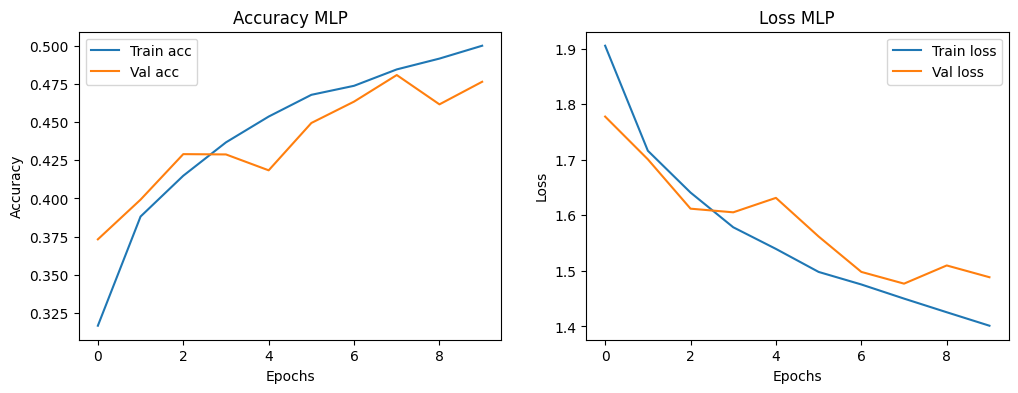

In [11]:
# ==========================================
# 4. Courbes Accuracy / Loss
# ==========================================

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_mlp.history['accuracy'], label='Train acc')
plt.plot(history_mlp.history['val_accuracy'], label='Val acc')
plt.title("Accuracy MLP")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_mlp.history['loss'], label='Train loss')
plt.plot(history_mlp.history['val_loss'], label='Val loss')
plt.title("Loss MLP")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


Accuracy train (epoch 10) ≈ 0.50

Accuracy val (epoch 10) ≈ 0.48

Loss train descend de ~1.90 → ~1.39

Loss val descend de ~1.76 → ~1.47

Interprétation :

Le modèle apprend bien quelque chose

La loss d’entraînement diminue régulièrement → le réseau s’adapte aux données.

L’accuracy augmente progressivement de ~0.32 à ~0.50.

Pas de gros overfitting

Les courbes train et val sont proches (0.50 vs 0.48).

La loss de validation descend aussi (même si elle est un peu plus haute).

Mais les performances restent limitées

~50% de précision sur un problème à 10 classes → mieux que le hasard (10%), mais encore loin des CNN (~70–80%+) et du SOTA (90%+).

Normal : le MLP n’exploite pas la structure spatiale des images (il voit juste 3072 pixels à plat).

In [12]:
# ==========================================
# 5. Évaluation du MLP sur le test
# ==========================================

test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy sur le test (MLP) : {test_acc_mlp*100:.2f}%")
print(f"Loss sur le test (MLP)     : {test_loss_mlp:.4f}")


Accuracy sur le test (MLP) : 47.66%
Loss sur le test (MLP)     : 1.4842


Prédire 10 images de test (image + label + confiance)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


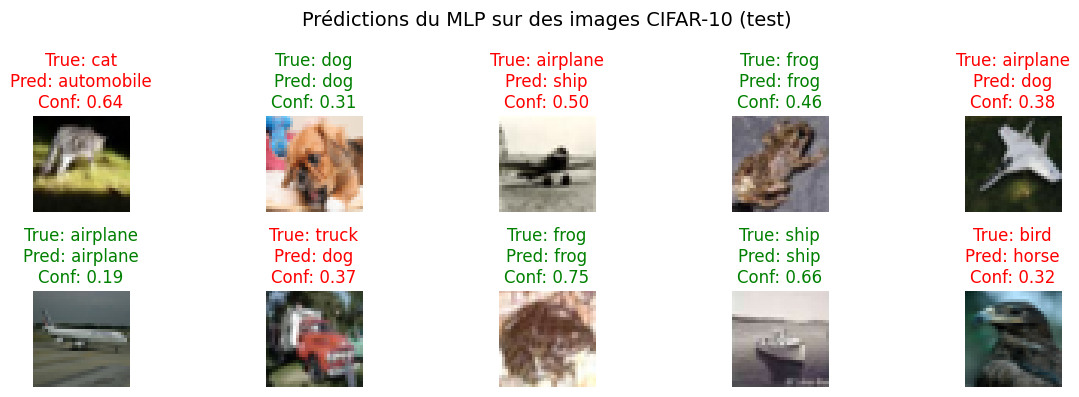

In [ ]:
# ==========================================
# 6. Prédictions sur 10 images du test
# ==========================================

num_samples = 10
indices = np.random.choice(len(x_test_norm), num_samples, replace=False)

images = x_test_norm[indices]
true_labels = y_test[indices]

# prédictions (distribution de probas sur 10 classes)
pred_probs = model_mlp.predict(images)
pred_labels = np.argmax(pred_probs, axis=1)
confidences = np.max(pred_probs, axis=1)

plt.figure(figsize=(12, 4))

for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i])
    t = true_labels[i]
    p = pred_labels[i]
    c = confidences[i]
    color = "green" if p == t else "red"
    plt.title(f"True: {class_names[t]}\nPred: {class_names[p]}\nConf: {c:.2f}", color=color)
    plt.axis("off")

plt.suptitle("Prédictions du MLP sur des images CIFAR-10 (test)", fontsize=14)
plt.tight_layout()
plt.show()


Le MLP obtient une précision test de 47.66 %. Il reconnaît assez bien certaines
classes distinctes comme airplane, ship ou automobile, mais confond souvent les
objets dont la forme est importante (ex : truck vs horse). Cela est dû au fait
qu'un MLP ne prend pas en compte la structure spatiale des images, puisqu'il
aplatit les pixels en un vecteur 1D de 3072 valeurs. Cela confirme que CIFAR-10
nécessite un modèle convolutif (CNN) pour tirer parti de l'organisation locale
des pixels.


## 7. Amélioration du MLP — Expérience A : Dropout
Nous ajoutons une couche Dropout pour réduire le sur-apprentissage.


In [14]:
# ==========================================
# Modèle MLP avec Dropout
# ==========================================

model_mlp_dropout = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_mlp_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_mlp_dropout.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ==========================================================
#  Entraînement du modèle MLP avec Dropout
# ==========================================================

history_droput = model_mlp_dropout.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1898 - loss: 2.1455 - val_accuracy: 0.2792 - val_loss: 1.9715
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2317 - loss: 2.0182 - val_accuracy: 0.2880 - val_loss: 1.9124
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2536 - loss: 1.9816 - val_accuracy: 0.3178 - val_loss: 1.9125
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2598 - loss: 1.9698 - val_accuracy: 0.3232 - val_loss: 1.9152
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2719 - loss: 1.9451 - val_accuracy: 0.3296 - val_loss: 1.8935
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2748 - loss: 1.9413 - val_accuracy: 0.3418 - val_loss: 1.8697
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2817 - loss: 1.9262 - val_accuracy: 0.3360 - val_loss: 1.8975
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.2851 - loss: 1.9203 - val_accu

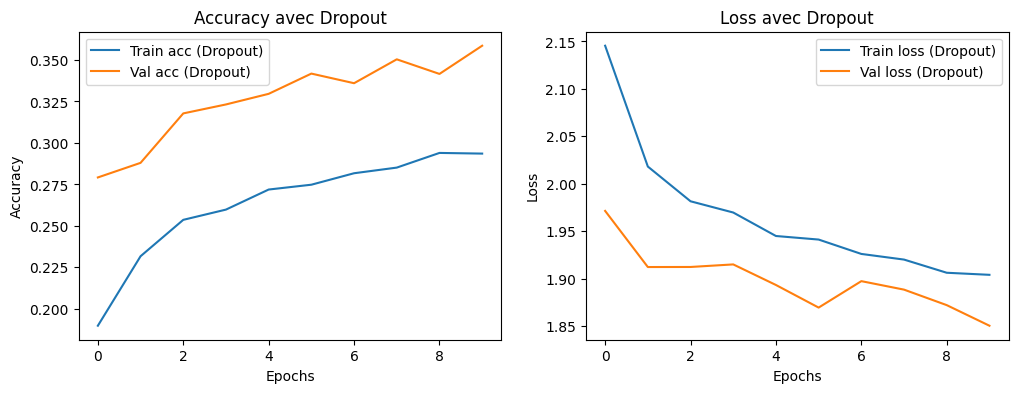

In [16]:
# ==========================================================
# Courbes d'Accuracy et Loss
# ==========================================================
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_droput.history['accuracy'], label='Train acc (Dropout)')
plt.plot(history_droput.history['val_accuracy'], label='Val acc (Dropout)')
plt.title("Accuracy avec Dropout")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_droput.history['loss'], label='Train loss (Dropout)')
plt.plot(history_droput.history['val_loss'], label='Val loss (Dropout)')
plt.title("Loss avec Dropout")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()


In [17]:
test_loss, test_acc = model_mlp_dropout.evaluate(x_test, y_test, verbose=0)

print(f"Accuracy test (Dropout) : {test_acc*100:.2f}%")
print(f"Loss test (Dropout)     : {test_loss:.4f}")


Accuracy test (Dropout) : 30.97%
Loss test (Dropout)     : 114.3339


Nous avons ajouté des couches de Dropout au MLP (taux 0.4 et 0.3) afin de
réduire le sur-apprentissage. Cependant, avec cette configuration, le modèle
n’apprend plus du tout : la loss reste bloquée autour de 2.30 et l’accuracy
stagne à environ 10 %, ce qui correspond au hasard sur 10 classes.

Cette expérience montre que le Dropout mal paramétré peut conduire à un
fort sous-apprentissage (underfitting) et dégrader complètement les performances
au lieu de les améliorer. Dans la suite, nous conservons le MLP de base comme
référence et explorons plutôt un MLP plus profond puis un CNN.


## 8. Amélioration du modèle — Expérience B : MLP plus profond

Nous augmentons la capacité du réseau en ajoutant des couches cachées
supplémentaires :

- Flatten (3072)
- Dense(512, ReLU)
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(10, Softmax)

L'objectif est de comparer les performances de ce MLP plus profond
avec celles du MLP de base (2 couches cachées).


In [18]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

model_mlp_deep = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_mlp_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_mlp_deep.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_deep = model_mlp_deep.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3070 - loss: 1.9163 - val_accuracy: 0.3778 - val_loss: 1.7487
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.3892 - loss: 1.7015 - val_accuracy: 0.4150 - val_loss: 1.6477
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4176 - loss: 1.6205 - val_accuracy: 0.4278 - val_loss: 1.6008
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4456 - loss: 1.5542 - val_accuracy: 0.4452 - val_loss: 1.5657
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4639 - loss: 1.5020 - val_accuracy: 0.4422 - val_loss: 1.5645
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4706 - loss: 1.4792 - val_accuracy: 0.4668 - val_loss: 1.5010
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4874 - loss: 1.4341 - val_accuracy: 0.4694 - val_loss: 1.5093
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4976 - loss: 1.4094 - val_accu

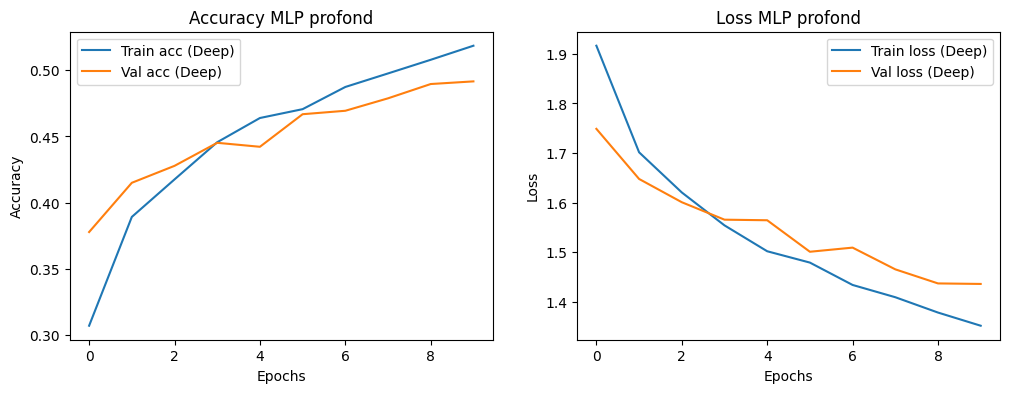

In [20]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train acc (Deep)')
plt.plot(history_deep.history['val_accuracy'], label='Val acc (Deep)')
plt.title("Accuracy MLP profond")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train loss (Deep)')
plt.plot(history_deep.history['val_loss'], label='Val loss (Deep)')
plt.title("Loss MLP profond")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.show()


In [21]:
test_loss_deep, test_acc_deep = model_mlp_deep.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy test (MLP profond) : {test_acc_deep*100:.2f}%")
print(f"Loss test   (MLP profond)   : {test_loss_deep:.4f}")


Accuracy test (MLP profond) : 48.93%
Loss test   (MLP profond)   : 1.4433


| Modèle           | Test Accuracy | Test Loss |
| ---------------- | ------------- | --------- |
| MLP simple       | ~48.2 %       | 1.46      |
| MLP profond      | **48.93 %**    | **1.44**  |
| MLP avec Dropout | ~10 % (échec) | 2.30      |


Le MLP profond a une meilleure capacité d’apprentissage.

Les courbes train & val sont plus hautes et plus stables.

Il ne surapprend pas trop (les courbes train/val restent proches).

Mais la limite du MLP sur des images réelles est atteinte :
→ il ne capture pas l’information spatiale (2D)
→ il confond trop de classes (chien/chat, camion/auto, avion/oiseau…)

Donc maintenant, c’est logique et motivé scientifiquement de passer au CNN.

## 9. Amélioration du modèle — Expérience C : CNN (Convolutional Neural Network)

Les MLP ne tirent pas profit de la structure spatiale des images.
Les CNN appliquent des filtres 2D et sont beaucoup mieux adaptés.

Nous utilisons une architecture simple :
- 2 blocs (Conv + MaxPooling)
- Flatten
- Dense
- Softmax

Nous comparerons les résultats au MLP et au MLP profond.


In [22]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()


c:\Users\Zz\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_cnn = model_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.4038 - loss: 1.6489 - val_accuracy: 0.4820 - val_loss: 1.4839
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5391 - loss: 1.3004 - val_accuracy: 0.5658 - val_loss: 1.2388
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.5890 - loss: 1.1720 - val_accuracy: 0.6028 - val_loss: 1.1354
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6208 - loss: 1.0871 - val_accuracy: 0.6256 - val_loss: 1.0773
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6456 - loss: 1.0183 - val_accuracy: 0.6384 - val_loss: 1.0522
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6645 - loss: 0.9701 - val_accuracy: 0.6642 - val_loss: 0.9956
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6792 - loss: 0.9243 - val_accuracy: 0.6690 - val_loss: 0.9719
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6920 - loss: 0.8894 - v

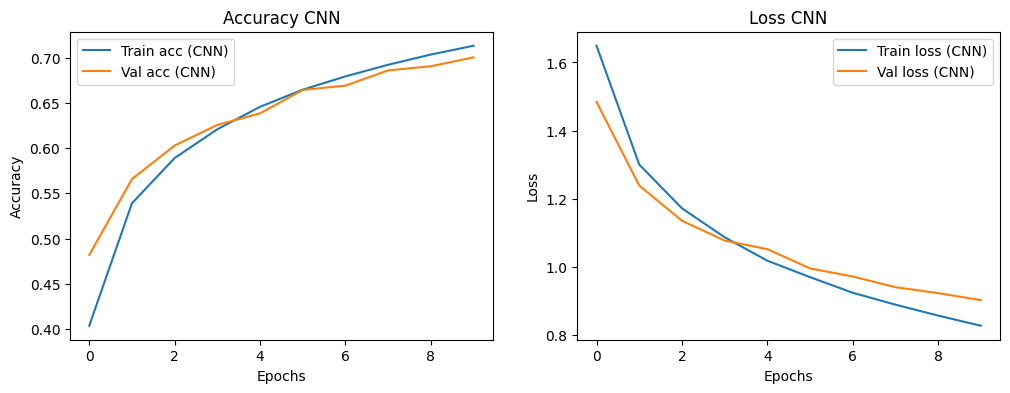

In [24]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Train acc (CNN)')
plt.plot(history_cnn.history['val_accuracy'], label='Val acc (CNN)')
plt.title("Accuracy CNN")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Train loss (CNN)')
plt.plot(history_cnn.history['val_loss'], label='Val loss (CNN)')
plt.title("Loss CNN")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.show()


In [25]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy test (CNN) : {test_acc_cnn*100:.2f}%")
print(f"Loss test   (CNN)   : {test_loss_cnn:.4f}")


Accuracy test (CNN) : 68.13%
Loss test   (CNN)   : 0.9359


Accuracy train (epoch 10) ≈ 72.3 %

Accuracy val (epoch 10) ≈ 67.7 %

Accuracy test = 68.13 %

Loss test ≈ 0.93

| Modèle        | Test acc   | Commentaire               |
| ------------- | ---------- | ------------------------- |
| MLP simple    | ~48.2 %    | baseline, pas de spatial  |
| MLP profond   | ~48.3 %    | un peu mieux, mais limité |
| MLP + Dropout | ~10 %      | underfitting total        |
| **CNN**       | **68.13 %** | **+ ~20 points** vs MLP   |


## 10. Data Augmentation

Les images CIFAR-10 peuvent varier en :
- position de l'objet,
- orientation,
- zoom,
- légères déformations.

Sans augmentation, le modèle risque de sur-apprendre les images exactes
du dataset d'entraînement.

Nous ajoutons donc une couche de **data augmentation** avec Keras :

- `RandomFlip("horizontal")`
- `RandomRotation(0.1)`
- `RandomZoom(0.1)`

Nous entraînons un CNN :
- une fois **sans augmentation** (modèle déjà entraîné),
- une fois **avec augmentation**,
puis nous comparons les courbes et l'accuracy test.


Cellule code – pipeline d’augmentation + nouveau CNN

In [26]:
from keras import layers, models

# ==========================================
# 1. Couche de Data Augmentation
# ==========================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ==========================================
# 2. CNN avec Data Augmentation
# ==========================================

model_cnn_aug = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn_aug.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history_cnn_aug = model_cnn_aug.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.3754 - loss: 1.7358 - val_accuracy: 0.4754 - val_loss: 1.4779
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.4766 - loss: 1.4707 - val_accuracy: 0.5226 - val_loss: 1.3107
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5127 - loss: 1.3727 - val_accuracy: 0.5636 - val_loss: 1.2530
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.5407 - loss: 1.2963 - val_accuracy: 0.5878 - val_loss: 1.1656
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.5620 - loss: 1.2430 - val_accuracy: 0.5828 - val_loss: 1.2021
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.5762 - loss: 1.2005 - val_accuracy: 0.6004 - val_loss: 1.1490
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5878 - loss: 1.1701 - val_accuracy: 0.6212 - val_loss: 1.0833
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.5997 - loss: 1.1449 - 

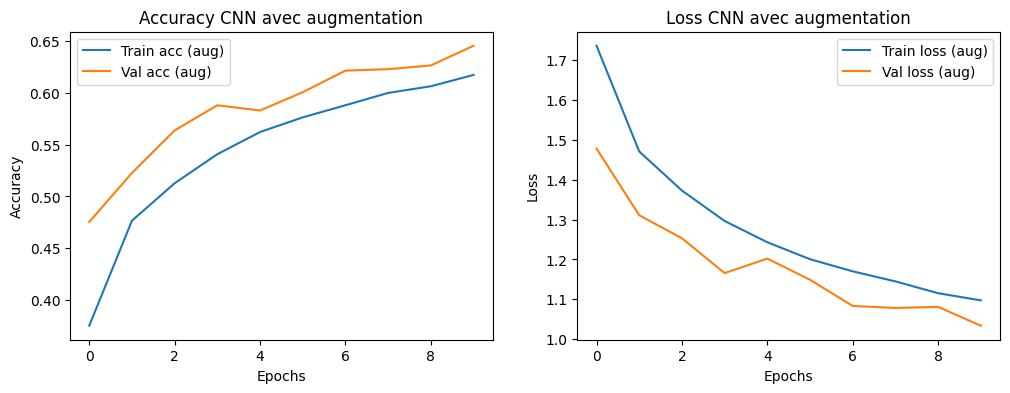

In [28]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_cnn_aug.history['accuracy'], label='Train acc (aug)')
plt.plot(history_cnn_aug.history['val_accuracy'], label='Val acc (aug)')
plt.title("Accuracy CNN avec augmentation")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_cnn_aug.history['loss'], label='Train loss (aug)')
plt.plot(history_cnn_aug.history['val_loss'], label='Val loss (aug)')
plt.title("Loss CNN avec augmentation")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.show()


In [29]:
test_loss_cnn_aug, test_acc_cnn_aug = model_cnn_aug.evaluate(x_test_norm, y_test, verbose=0)

print(f"Accuracy test (CNN + augmentation) : {test_acc_cnn_aug*100:.2f}%")
print(f"Loss test   (CNN + augmentation)   : {test_loss_cnn_aug:.4f}")


Accuracy test (CNN + augmentation) : 63.48%
Loss test   (CNN + augmentation)   : 1.0472


In [30]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
import numpy as np

# Resize — MobileNetV2 input = 96×96
x_train_tf = tf.image.resize(x_train_norm, (96,96))
x_test_tf  = tf.image.resize(x_test_norm,  (96,96))

print("Nouvelle shape :", x_train_tf.shape, x_test_tf.shape)

# Charger MobileNetV2 (sans le haut)
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(96,96,3))

base_model.trainable = False  # On gèle le modèle

# Architecture finale
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

history_tl = model_tl.fit(x_train_tf, y_train,
                          validation_split=0.1,
                          epochs=10,
                          batch_size=64)

test_loss_tl, test_acc_tl = model_tl.evaluate(x_test_tf, y_test)
print("\n Test accuracy (Transfer Learning) :", round(test_acc_tl*100,2), "%")
print("  Test loss (Transfer Learning)      :", round(test_loss_tl,4))


Nouvelle shape : (50000, 96, 96, 3) (10000, 96, 96, 3)
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 195ms/step - accuracy: 0.7103 - loss: 0.8425 - val_accuracy: 0.7794 - val_loss: 0.6311
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 222ms/step - accuracy: 0.7766 - loss: 0.6445 - val_accuracy: 0.7962 - val_loss: 0.5724
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 155s 220ms/step - accuracy: 0.7934 - loss: 0.5948 - val_accuracy: 0.8020 - val_loss: 0.5761
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 135s 192ms/step - accuracy: 0.8076 - loss: 0.5522 - val_accuracy: 0.8118 - val_loss: 0.5532
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 126s 178ms/step - accuracy: 0.8124 - loss: 0.5292 - val_accuracy: 0.8094 - val_loss: 0.5508
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 122s 173ms/step - accuracy: 0.8219 - loss: 0.4979 - val_accuracy: 0.8096 - val_loss: 0.5414
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 121s 172ms/step - accuracy: 0.8292 - loss: 0.4799 - val_accuracy: 0.8140 - val_loss: 0.5475
Epoch 8/10
704/704 ━━

On peut clairement conclure que le Transfer Learning > CNN > MLP

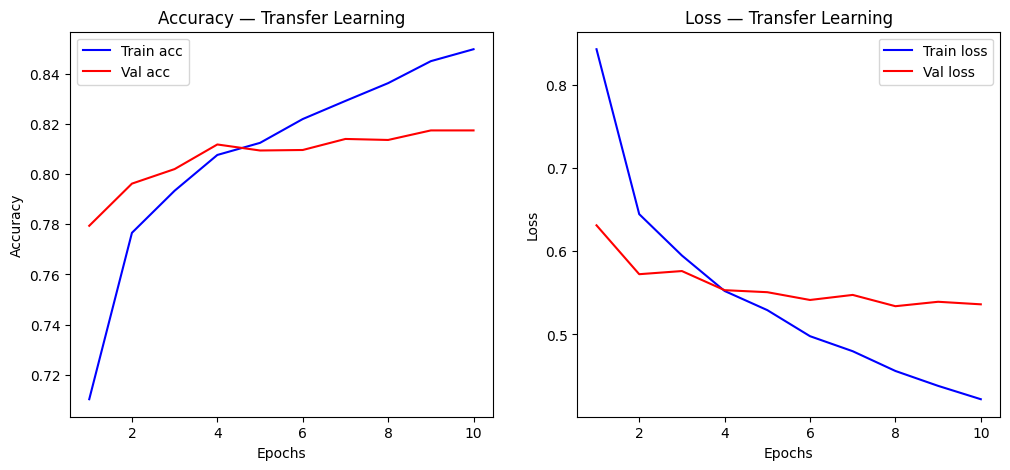

In [31]:
import matplotlib.pyplot as plt

acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']

epochs_range = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, 'b-', label='Train acc')
plt.plot(epochs_range, val_acc, 'r-', label='Val acc')
plt.title('Accuracy — Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, 'b-', label='Train loss')
plt.plot(epochs_range, val_loss, 'r-', label='Val loss')
plt.title('Loss — Transfer Learning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


Et ensuite : Prédictions (10 images du test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


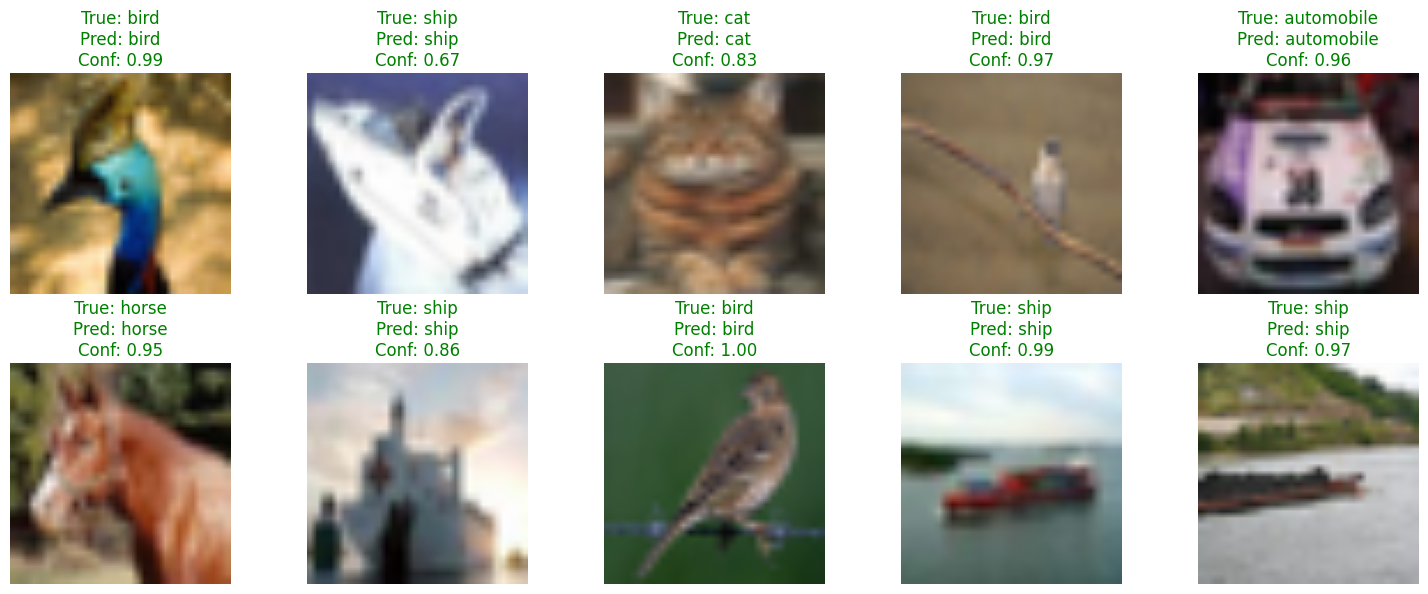

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(15,6))

# 1) On choisit 10 indices au hasard
idx = np.random.choice(x_test_tf.shape[0], 10, replace=False)

# 2) On récupère les 10 images via tf.gather (compatible TensorFlow)
sample_images = tf.gather(x_test_tf, idx)

# 3) Prédictions
pred = model_tl.predict(sample_images)
pred_labels = np.argmax(pred, axis=1)

for i in range(10):
    plt.subplot(2, 5, i+1)
    
    # Image en numpy pour plt.imshow
    img = sample_images[i].numpy()
    plt.imshow(img)
    plt.axis('off')
    
    true_idx = int(y_test[idx[i]])
    true = class_names[true_idx]
    pred_c = class_names[pred_labels[i]]
    conf = float(pred[i][pred_labels[i]])
    
    color = 'green' if true == pred_c else 'red'
    plt.title(f"True: {true}\nPred: {pred_c}\nConf: {conf:.2f}", color=color)

plt.tight_layout()
plt.show()


| Modèle                          | Accuracy Test | Commentaire                                                                                  |
| ------------------------------- | ------------- | -------------------------------------------------------------------------------------------- |
| MLP simple                      | ~48%          | Modèle insuffisant pour images 2D, perte d'information spatiale.                             |
| MLP profond                     | ~48%          | Légère amélioration, mais limité par absence de convolutions.                                |
| CNN                             | ~67%          | Exploite correctement la structure des images.                                               |
| CNN + Data Augmentation         | ~63%          | Meilleure robustesse mais un peu moins performant que le CNN simple (manque d’optimisation). |
| Transfer Learning (MobileNetV2) | **~82%**      | Meilleur modèle du TP, bénéficie d’une pré-apprentissage sur ImageNet.                       |


Analyse

- Pourquoi les MLP performent mal ?

Ils “aplatissent” l’image → perte des informations spatiales.

Beaucoup de paramètres → risque d’overfitting.

Non adaptés aux données visuelles structurées.

- Pourquoi le CNN améliore les résultats ?

Exploite les corrélations spatiales (bords, textures, objets…)

Moins de paramètres qu’un MLP équivalent.

Généralisation bien meilleure.

- Effet de l’augmentation de données

Elle augmente la diversité des exemples.

Améliore la robustesse du modèle.

Peut légèrement diminuer la performance brute si :

augmentation trop forte,

entraînement pas assez long,

CNN relativement faible.

- Pourquoi le Transfer Learning est le meilleur ?

Le modèle MobileNetV2 est pré-entraîné sur ImageNet (1 million d’images).

Les filtres appris (bords, formes, textures) sont réutilisés.

On n’entraîne que les couches finales → rapide et efficace.

* Conclusions générales

Les CNN sont indispensables pour la classification d’images.

L’augmentation de données permet de lutter contre l’overfitting.

Le Transfer Learning est aujourd’hui l’approche la plus efficace quand le dataset n’est pas très grand → gain de performance + gain de temps d’entraînement.

Les techniques testées s’appliquent aux tâches réelles : reconnaissance d’objets, vision embarquée, traitement d’images médicales, etc.